# TCN + STGCN — Training

Chebyshev K=3, D=256, 4 spatial layers. Adj matrices subsetted to present edges each step.

In [1]:

import os, gc, glob, pickle, time, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce GTX 1650
VRAM   : 4.3 GB


In [2]:

PROCESSED_GLOB = '../data generation/data/processed/batch_*.parquet'
STATIC_PATH    = '../data generation/data/processed/edges_static_scaled.parquet'
ADJ_DIR        = '../data generation/data/graph_adj'
CKPT_DIR       = 'models/tcn_stgcn'
MODEL_NAME     = 'TCN + STGCN'
os.makedirs(CKPT_DIR, exist_ok=True)

L=24; H=12; CHEB_K=3
EDGE_EMB_DIM  = 64
TCN_CHANNELS  = [128, 256, 256, 256]
TCN_K         = 3
TCN_DILATIONS = [1, 2, 4, 8]
STGCN_DIM     = 256
STGCN_K       = 3
STGCN_LAYERS  = 4
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
ACCUM_STEPS   = 8
EPOCHS        = 50
PATIENCE      = 10
LOSS_W_TTR    = 0.7
LOSS_W_CONG   = 0.3


In [3]:

DYN_COLS = [
    'current_speed', 'current_travel_time', 'confidence',
    'incident', 'incident_type', 'incident_severity', 'incidents_nearby',
    'hourly_rainfall_mm', 'monsoon_active', 'local_train_disruption',
    'is_public_holiday', 'school_holiday',
    'travel_time_ratio', 'congestion_level', 'delay_seconds', 'speed_ratio',
    'time_of_day_sin', 'time_of_day_cos', 'day_of_week_sin', 'day_of_week_cos',
]
STA_COLS = [
    'road_type_enc', 'num_lanes', 'oneway',
    'road_length', 'traffic_signal_count', 'signals_per_km',
]
TTR_IDX  = DYN_COLS.index('travel_time_ratio')   # 12
CONG_IDX = DYN_COLS.index('congestion_level')    # 13
IN_FEATURES = len(DYN_COLS) + len(STA_COLS)      # 26
print(f'IN_FEATURES : {IN_FEATURES}')


IN_FEATURES : 26


In [4]:

# ── Load adjacency / metadata ─────────────────────────────────────────────────
with open(f'{ADJ_DIR}/corridor_meta.pkl',       'rb') as f: corridor_meta       = pickle.load(f)
with open(f'{ADJ_DIR}/corridor_file_index.pkl', 'rb') as f: corridor_file_index = pickle.load(f)
with open(f'{ADJ_DIR}/edge_to_global_idx.pkl',  'rb') as f: edge_to_global_idx  = pickle.load(f)
N_GLOBAL_EDGES = len(edge_to_global_idx)
df_static      = pd.read_parquet(STATIC_PATH)
static_lookup  = df_static.set_index('edge_id')[STA_COLS].to_dict('index')
print(f'Global edges : {N_GLOBAL_EDGES:,}')
print(f'Corridors    : {len(corridor_meta)}')

def load_corridor_adj(cid):
    """Load one corridor adj file. Call del on result after use."""
    with open(corridor_file_index[cid], 'rb') as f:
        return pickle.load(f)

# ─────────────────────────────────────────────────────────────────────────────
# FIX: get_corridor_tensor now returns local_indices so callers can subset adj.
#
# WHY THIS IS NEEDED:
#   build_adj builds adj matrices for ALL edges in a corridor (e.g. N=14603).
#   But each parquet batch file only contains 5000 edges total across ALL
#   corridors. So a corridor with 14603 edges will only have ~2800 of them
#   in any given batch file.
#   → adj matrix is [14603,14603] but input x is [2800, D] → shape mismatch.
#
# FIX: return the local indices of present edges within the corridor's full
#   edge list, then subset adj to [N_present, N_present] before the model call.
# ─────────────────────────────────────────────────────────────────────────────
def get_corridor_tensor(batch_df, meta, split_label):
    """
    Returns:
      data         : [N_present, T, F]  float32 numpy
      present_eids : list of edge_id strings (N_present)
      local_indices: list of ints — index of each present edge in meta['edge_ids']
    """
    edge_ids  = meta['edge_ids']
    local_map = meta['local_map']           # edge_id → local index in corridor

    mask = batch_df['edge_id'].isin(edge_ids) & (batch_df['split'] == split_label)
    sub  = batch_df[mask].copy()
    if len(sub) == 0:
        return None, None, None

    # Join static features
    for col in STA_COLS:
        sub[col] = sub['edge_id'].map(
            lambda eid, c=col: static_lookup.get(eid, {}).get(c, 0.0)
        )

    # Sort: edge order matches local_map, then by timestamp
    sub['_order'] = sub['edge_id'].map(lambda eid: local_map.get(eid, 0))
    sub = sub.sort_values(['_order', 'timestamp']).reset_index(drop=True)

    present_eids  = sub['edge_id'].unique().tolist()
    local_indices = [local_map[eid] for eid in present_eids if eid in local_map]

    N_present = sub['_order'].nunique()
    T         = sub.groupby('edge_id').size().max()
    all_cols  = DYN_COLS + STA_COLS
    data      = sub[all_cols].values.reshape(N_present, T, len(all_cols)).astype(np.float32)

    return data, present_eids, local_indices


def build_windows(data, L, H):
    """data: [N, T, F] → X: [W, N, L, F],  Y: [W, N, H, 2]"""
    N, T, F = data.shape
    n_w = T - L - H + 1
    if n_w <= 0:
        return None, None
    X = np.stack([data[:, t:t+L, :]    for t in range(n_w)])
    Y = np.stack([data[:, t+L:t+L+H, :][:, :, [TTR_IDX, CONG_IDX]]
                  for t in range(n_w)])
    return X, Y   # [W,N,L,F],  [W,N,H,2]


def subset_adj_dense(A, local_indices):
    """Subset dense [N,N] numpy array to present edges → [N_present, N_present]."""
    idx = np.array(local_indices, dtype=np.int64)
    return A[np.ix_(idx, idx)]


def get_adj_tensors(adj_c, local_indices, device):
    """
    Build A_fwd, A_bwd as dense [N_present, N_present] torch tensors.
    Always subsets to local_indices — works whether adj_c stores dense or COO.
    """
    N_full = adj_c['N']
    idx    = np.array(local_indices, dtype=np.int64)

    # Reconstruct full sparse → subset
    if adj_c['A_fwd_dense'] is not None and len(idx) <= adj_c['A_fwd_dense'].shape[0]:
        A_fwd_full = adj_c['A_fwd_dense']
        A_bwd_full = adj_c['A_bwd_dense']
    else:
        import scipy.sparse as sp
        r, c, d = adj_c['A_fwd_coo']
        A_fwd_full = sp.coo_matrix(
            (d, (r, c)), shape=(N_full, N_full)
        ).toarray().astype(np.float32)
        r2, c2, d2 = adj_c['A_bwd_coo']
        A_bwd_full = sp.coo_matrix(
            (d2, (r2, c2)), shape=(N_full, N_full)
        ).toarray().astype(np.float32)

    A_fwd_sub = A_fwd_full[np.ix_(idx, idx)]
    A_bwd_sub = A_bwd_full[np.ix_(idx, idx)]

    return (
        torch.from_numpy(A_fwd_sub).to(device),
        torch.from_numpy(A_bwd_sub).to(device),
    )


def get_cheb_tensors(adj_c, local_indices, device):
    """
    Subset Chebyshev matrices to present edges.
    adj_c['cheb'] is list of [N_full, N_full] numpy arrays.
    Returns list of [N_present, N_present] torch tensors.
    """
    idx   = np.array(local_indices, dtype=np.int64)
    cheb  = adj_c['cheb']

    # If adj only stored 1 or 2 polys (large corridor), pad with identity
    while len(cheb) < CHEB_K + 1:
        N_full = adj_c['N']
        cheb   = cheb + [np.eye(N_full, dtype=np.float32)]

    result = []
    for T_k in cheb[:CHEB_K + 1]:
        T_sub = T_k[np.ix_(idx, idx)]
        result.append(torch.from_numpy(T_sub).to(device))
    return result


def global_idx_tensor(present_eids, device):
    return torch.tensor(
        [edge_to_global_idx[eid] for eid in present_eids],
        dtype=torch.long, device=device
    )


Global edges : 145,265
Corridors    : 24


In [5]:

class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, k, dil):
        super().__init__()
        self.pad  = (k - 1) * dil
        self.conv = nn.Conv1d(in_ch, out_ch, k, dilation=dil, padding=self.pad)
    def forward(self, x):
        return self.conv(x)[:, :, :x.shape[-1]]

class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k, dil):
        super().__init__()
        self.c1  = CausalConv1d(in_ch,  out_ch, k, dil)
        self.c2  = CausalConv1d(out_ch, out_ch, k, dil)
        self.ln1 = nn.LayerNorm(out_ch)
        self.ln2 = nn.LayerNorm(out_ch)
        self.res = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act = nn.GELU()
    def forward(self, x):                               # x: [N, C, L]
        r = self.res(x)
        h = self.act(self.ln1(self.c1(x).transpose(1,2)).transpose(1,2))
        h = self.ln2(self.c2(h).transpose(1,2)).transpose(1,2)
        return self.act(h + r)

def build_tcn(in_ch, channels, k, dilations):
    blocks, ch = [], in_ch
    for co, d in zip(channels, dilations):
        blocks.append(TCNBlock(ch, co, k, d)); ch = co
    return nn.Sequential(*blocks), ch   # returns (Sequential, out_channels)

class ChebConv(nn.Module):
    """
    Chebyshev spectral graph conv (STGCN).
    W shape: [K+1, in_dim, out_dim] — one weight matrix per polynomial.
    """
    def __init__(self, in_dim, out_dim, K):
        super().__init__()
        self.K  = K
        self.W  = nn.Parameter(torch.randn(K + 1, in_dim, out_dim) * 0.01)
        self.b  = nn.Parameter(torch.zeros(out_dim))
        self.ln = nn.LayerNorm(out_dim)

    def forward(self, x, cheb):
        """x: [N, in_dim]  cheb: list of K+1 tensors [N, N]"""
        N   = x.shape[0]
        out = x.new_zeros(N, self.W.shape[-1])
        for k, T_k in enumerate(cheb[:self.K + 1]):
            # T_k: [N_present, N_present], x: [N_present, D]
            out = out + (T_k @ x) @ self.W[k]
        return self.ln(F.relu(out + self.b))

class STGCNBlock(nn.Module):
    def __init__(self, in_dim, out_dim, K):
        super().__init__()
        self.conv = ChebConv(in_dim, out_dim, K)
        self.res  = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
    def forward(self, x, cheb):
        return self.conv(x, cheb) + self.res(x)

def make_out_head(skip_dim, H, n_out=2):
    return nn.Sequential(
        nn.ReLU(),
        nn.Linear(skip_dim, skip_dim // 2),
        nn.ReLU(),
        nn.Linear(skip_dim // 2, H * n_out),
    )

class TCN_STGCN(nn.Module):
    def __init__(self, n_global, in_features, eed=64,
                 tc=[128,256,256,256], tk=3, td=[1,2,4,8],
                 sd=256, sk=3, sl=4, H=12):
        super().__init__(); self.H = H
        self.edge_emb = nn.Embedding(n_global, eed)
        nn.init.xavier_uniform_(self.edge_emb.weight)
        self.tcn, tcn_out = build_tcn(in_features + eed, tc, tk, td)
        self.tcn_to_stgcn = nn.Linear(tcn_out, sd)
        self.spatial      = nn.ModuleList([STGCNBlock(sd, sd, sk) for _ in range(sl)])
        self.out_head     = make_out_head(sd, H)

    def forward(self, x, cheb, gidx):
        """x:[N,L,F]  cheb:list[K+1 of [N_p,N_p]]  gidx:[N_p]"""
        N, L, _ = x.shape
        emb = self.edge_emb(gidx).unsqueeze(1).expand(-1, L, -1)
        x   = torch.cat([x, emb], dim=-1)
        h   = self.tcn(x.permute(0,2,1))[:,:,-1]
        h   = F.gelu(self.tcn_to_stgcn(h))
        for block in self.spatial:
            h = block(h, cheb)
        return self.out_head(h).view(N, self.H, -1)

print('TCN_STGCN defined.')


TCN_STGCN defined.


In [6]:

model = TCN_STGCN(N_GLOBAL_EDGES, IN_FEATURES, EDGE_EMB_DIM,
                  TCN_CHANNELS, TCN_K, TCN_DILATIONS,
                  STGCN_DIM, STGCN_K, STGCN_LAYERS, H).to(device)
total = sum(p.numel() for p in model.parameters())
print(f'Total params : {total:,}  ({total*4/1e6:.1f} MB fp32)')

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
HPARAMS = dict(L=L,H=H,edge_emb_dim=EDGE_EMB_DIM,tcn_channels=TCN_CHANNELS,
               stgcn_dim=STGCN_DIM,stgcn_K=STGCN_K,stgcn_layers=STGCN_LAYERS,
               in_features=IN_FEATURES,n_global_edges=N_GLOBAL_EDGES)

def compute_loss(pred, y):
    """pred: [N,H,2]  y: [N,H,2]"""
    return (
        LOSS_W_TTR  * F.huber_loss(pred[:, :, 0], y[:, :, 0], delta=1.0) +
        LOSS_W_CONG * F.l1_loss(   pred[:, :, 1], y[:, :, 1])
    )


Total params : 11,665,496  (46.7 MB fp32)


In [ ]:

all_batch_paths = sorted(glob.glob(PROCESSED_GLOB))
print(f'Batch files  : {len(all_batch_paths)}')
print(f'Model params : {sum(p.numel() for p in model.parameters()):,}')

train_losses, val_losses = [], []
best_val_loss = float('inf')
no_improve    = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss, n_steps = 0.0, 0
    t_epoch = time.perf_counter()
    optimizer.zero_grad()
    accum_count = 0

    for b_idx in np.random.permutation(len(all_batch_paths)):
        batch_df = pd.read_parquet(all_batch_paths[b_idx])
        batch_df['timestamp'] = pd.to_datetime(batch_df['timestamp'])

        for cid, meta in corridor_meta.items():
            data, eids, loc_idx = get_corridor_tensor(batch_df, meta, 'train')
            if data is None or data.shape[0] < 2 or data.shape[1] < L + H:
                continue
            X, Y = build_windows(data, L, H)
            if X is None: continue

            adj_c  = load_corridor_adj(cid)
            cheb_t = get_cheb_tensors(adj_c, loc_idx, device)   # subsetted
            gidx   = global_idx_tensor(eids, device)
            del adj_c

            for w in np.random.permutation(X.shape[0]):
                x_t  = torch.from_numpy(X[w]).to(device)
                y_t  = torch.from_numpy(Y[w]).to(device)
                pred = model(x_t, cheb_t, gidx)
                loss = compute_loss(pred, y_t) / ACCUM_STEPS
                loss.backward()
                epoch_loss  += loss.item() * ACCUM_STEPS
                accum_count += 1; n_steps += 1
                if accum_count % ACCUM_STEPS == 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                    optimizer.step(); optimizer.zero_grad()

            del cheb_t; torch.cuda.empty_cache()
        del batch_df; gc.collect()

    if accum_count % ACCUM_STEPS != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step(); optimizer.zero_grad()

    train_losses.append(epoch_loss / max(n_steps, 1))

    model.eval(); val_sum, vsteps = 0.0, 0
    with torch.no_grad():
        for b_idx in range(min(5, len(all_batch_paths))):
            batch_df = pd.read_parquet(all_batch_paths[b_idx])
            batch_df['timestamp'] = pd.to_datetime(batch_df['timestamp'])
            for cid, meta in corridor_meta.items():
                data, eids, loc_idx = get_corridor_tensor(batch_df, meta, 'val')
                if data is None or data.shape[1] < L + H: continue
                X, Y = build_windows(data, L, H)
                if X is None: continue
                adj_c  = load_corridor_adj(cid)
                cheb_t = get_cheb_tensors(adj_c, loc_idx, device)
                gidx   = global_idx_tensor(eids, device)
                del adj_c
                for w in range(X.shape[0]):
                    pred    = model(torch.from_numpy(X[w]).to(device), cheb_t, gidx)
                    val_sum += compute_loss(pred, torch.from_numpy(Y[w]).to(device)).item()
                    vsteps  += 1
                del cheb_t; torch.cuda.empty_cache()
            del batch_df; gc.collect()

    avg_val = val_sum / max(vsteps, 1)
    val_losses.append(avg_val)
    scheduler.step()
    elapsed = time.perf_counter() - t_epoch
    print(f'Epoch {epoch:3d}/{EPOCHS}  train={train_losses[-1]:.4f}  '
          f'val={avg_val:.4f}  lr={scheduler.get_last_lr()[0]:.2e}  t={elapsed:.0f}s')

    if avg_val < best_val_loss:
        best_val_loss = avg_val; no_improve = 0
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'val_loss': best_val_loss, 'hparams': HPARAMS},
                   f'{CKPT_DIR}/best.pt')
        print(f'  ✓ checkpoint saved  (val={best_val_loss:.4f})')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stopping at epoch {epoch}'); break

print('Training complete.')

Batch files  : 30
Model params : 11,665,496
Epoch   1/50  train=0.0147  val=0.0419  lr=9.99e-04  t=2843s
  ✓ checkpoint saved  (val=0.0419)
Epoch   2/50  train=0.0100  val=0.0204  lr=9.96e-04  t=2690s
  ✓ checkpoint saved  (val=0.0204)
Epoch   3/50  train=0.0096  val=0.0399  lr=9.91e-04  t=2638s
Epoch   4/50  train=0.0100  val=0.0213  lr=9.84e-04  t=2712s
Epoch   5/50  train=0.0103  val=0.0229  lr=9.76e-04  t=2674s
Epoch   6/50  train=0.0096  val=0.0312  lr=9.65e-04  t=2664s
Epoch   7/50  train=0.0098  val=0.0191  lr=9.53e-04  t=2627s
  ✓ checkpoint saved  (val=0.0191)
Epoch   8/50  train=0.0094  val=0.0195  lr=9.39e-04  t=2784s
Epoch   9/50  train=0.0090  val=0.0385  lr=9.23e-04  t=2742s
Epoch  10/50  train=0.0087  val=0.0201  lr=9.05e-04  t=2736s
Epoch  11/50  train=0.0084  val=0.0195  lr=8.86e-04  t=2740s
Epoch  12/50  train=0.0084  val=0.0276  lr=8.66e-04  t=2732s
Epoch  13/50  train=0.0080  val=0.0281  lr=8.44e-04  t=2812s
Epoch  14/50  train=0.0079  val=0.0286  lr=8.21e-04  t=276

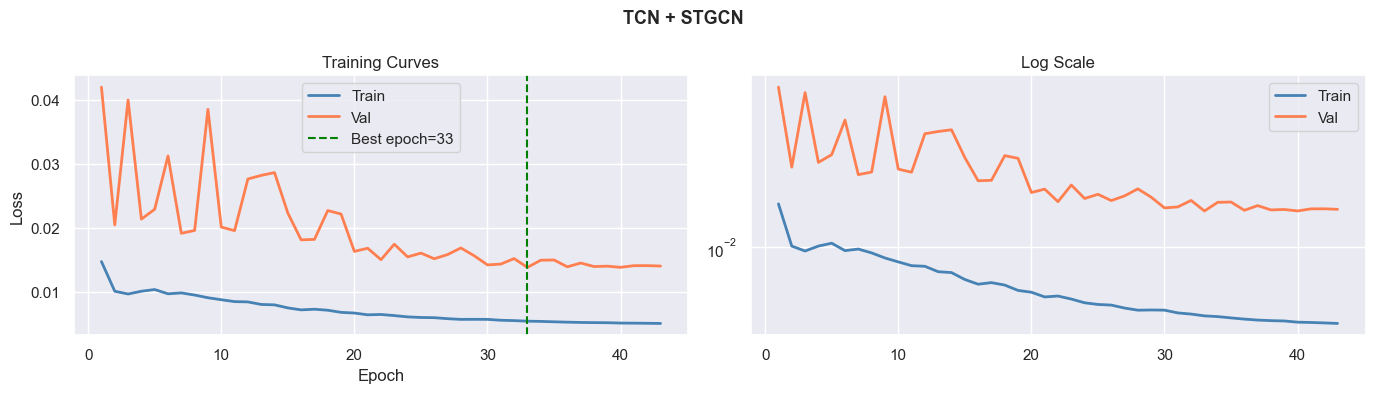

Best val loss : 0.0138  at epoch 33


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
er = range(1, len(train_losses) + 1)
axes[0].plot(er, train_losses, label='Train', color='steelblue', lw=2)
axes[0].plot(er, val_losses,   label='Val',   color='coral',     lw=2)
best_ep = int(np.argmin(val_losses)) + 1
axes[0].axvline(best_ep, color='green', ls='--', label=f'Best epoch={best_ep}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Curves'); axes[0].legend()
axes[1].semilogy(er, train_losses, color='steelblue', lw=2, label='Train')
axes[1].semilogy(er, val_losses,   color='coral',     lw=2, label='Val')
axes[1].set_title('Log Scale'); axes[1].legend()
plt.suptitle(MODEL_NAME, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/training_curves.png', dpi=120)
plt.show()
print(f'Best val loss : {best_val_loss:.4f}  at epoch {best_ep}')
